
# Disease Symptom Prediction - Model Explainability Using SHAP

## Project

AI Disease Prediction System

## Objective

The objective of this notebook is to interpret the trained machine
learning model using SHAP (SHapley Additive exPlanations).

The analysis focuses on understanding how the trained model uses
symptom-related features when making disease predictions.

The workflow includes:

- Loading the trained machine learning pipeline
- Loading the processed dataset
- Recreating the train-test split
- Extracting transformed feature names
- Preparing data for SHAP analysis
- Calculating SHAP values for selected predictions
- Analyzing global feature importance
- Visualizing SHAP feature contributions
- Analyzing individual predictions
- Saving SHAP results and visualizations

### Important Interpretation Note

SHAP values describe the contribution of model features to a prediction.
They represent learned model behavior and should not be interpreted as
medical causation or clinical evidence.

---

**Author:** Shahbaj Tanvir Shawon

**Course:** CSE Project

**Notebook:** 04_SHAP.ipynb


# 1. Import Required Libraries

This section imports the libraries required for:

- Data manipulation
- Numerical operations
- Model loading
- SHAP explainability
- Visualization
- File and path management

In [1]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import shap

from joblib import load

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")
print("SHAP version:", shap.__version__)

Libraries imported successfully.
SHAP version: 0.52.0



# 2. Project Paths and Configuration

The trained machine learning pipeline generated by Notebook 3 will
be loaded from the models directory.

The processed dataset will be loaded from the processed data directory.

All project paths are centralized to improve maintainability and
reduce path-related errors.

In [2]:

# --------------------------------------------------
# Project Paths
# --------------------------------------------------

PROJECT_ROOT = Path("../")

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"

SHAP_OUTPUT_DIR = (
    PROCESSED_DATA_DIR / "shap_outputs"
)

SHAP_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Dataset path
DATA_FILE = (
    PROCESSED_DATA_DIR / "disease_clean.csv"
)

# Trained pipeline path
MODEL_PATH = (
    MODEL_DIR / "disease_prediction_pipeline.pkl"
)

# Configuration
TARGET_COLUMN = "Disease"

RANDOM_STATE = 42

print("Project configuration completed.")

print(f"Dataset path: {DATA_FILE}")
print(f"Model path: {MODEL_PATH}")
print(f"SHAP output directory: {SHAP_OUTPUT_DIR}")

Project configuration completed.
Dataset path: ..\data\processed\disease_clean.csv
Model path: ..\models\disease_prediction_pipeline.pkl
SHAP output directory: ..\data\processed\shap_outputs



# 3. Load Processed Dataset and Trained Pipeline

The processed dataset generated by Notebook 1 is loaded.

The complete trained pipeline generated by Notebook 3 is also loaded.

The saved pipeline includes:

1. Categorical feature preprocessing
2. Numerical feature scaling
3. The trained classification model

The pipeline will be used to reproduce the same transformations
that were applied during model development.

In [3]:

# Load processed dataset
df = pd.read_csv(DATA_FILE)

# Load trained pipeline
best_pipeline = load(MODEL_PATH)

print("Dataset and trained pipeline loaded successfully.")

print(f"Dataset shape: {df.shape}")

print(
    "Loaded model:",
    type(best_pipeline.named_steps["model"]).__name__
)

Dataset and trained pipeline loaded successfully.
Dataset shape: (4920, 19)
Loaded model: SVC



# 4. Dataset and Model Validation

Before performing SHAP analysis, we verify that:

- The dataset is not empty.
- The target column exists.
- The required engineered feature exists.
- The target variable has no missing values.
- The saved pipeline contains the required preprocessing and model steps.

These checks help identify configuration errors before the explainability
stage.

In [4]:

# Dataset validation

assert not df.empty, "Dataset is empty."

assert TARGET_COLUMN in df.columns, (
    "Target column not found."
)

assert "Symptom_Count" in df.columns, (
    "Symptom_Count feature not found."
)

assert df[TARGET_COLUMN].isnull().sum() == 0, (
    "Target contains missing values."
)

# Pipeline validation

assert hasattr(best_pipeline, "named_steps"), (
    "Loaded object is not a valid pipeline."
)

assert "preprocessor" in best_pipeline.named_steps, (
    "Preprocessor not found in pipeline."
)

assert "model" in best_pipeline.named_steps, (
    "Model not found in pipeline."
)

print("Dataset validation passed.")
print("Pipeline validation passed.")

print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print(f"Disease classes: {df[TARGET_COLUMN].nunique()}")

Dataset validation passed.
Pipeline validation passed.
Rows: 4920
Columns: 19
Disease classes: 41



# 5. Define Features and Target

The supervised learning problem is defined as:

**Input (X):** Symptom features and the Symptom_Count feature.

**Target (y):** Disease.

The same input features used during Notebook 3 will be used for SHAP
analysis.

This ensures that the explanation process is consistent with the
trained model.

In [5]:

# Separate features and target

X = df.drop(
    columns=[TARGET_COLUMN]
)

y = df[TARGET_COLUMN]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("Number of disease classes:", y.nunique())

print("\nFeature columns:")
print(X.columns.tolist())

Feature matrix shape: (4920, 18)
Target shape: (4920,)
Number of disease classes: 41

Feature columns:
['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17', 'Symptom_Count']



# 6. Recreate the Train-Test Split

Notebook 3 used an 80/20 stratified train-test split with random_state=42.

The same split configuration is recreated here so that the test
data used for interpretation corresponds to the previous experimental
setup.

The SHAP analysis will be performed on a subset of the test data
to reduce computational cost.

### Important

The test set is used for model evaluation and interpretation.
SHAP explanations do not create a new independent validation estimate.

In [6]:

# Recreate the same train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train/test split recreated successfully.")

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Train/test split recreated successfully.
Training samples: 3936
Testing samples: 984



# 7. Validate the Recreated Split

The recreated split should contain the same number of training and
testing records as the split used in Notebook 3.

We also verify that the model can generate predictions for the
recreated test data.

In [7]:

# Validate split sizes

assert len(X_train) == 3936, (
    "Unexpected training set size."
)

assert len(X_test) == 984, (
    "Unexpected testing set size."
)

# Validate model prediction capability

test_predictions = best_pipeline.predict(X_test)

assert len(test_predictions) == len(X_test), (
    "Prediction count does not match test data."
)

print("Split validation passed.")
print("Model prediction validation passed.")

print(f"Test predictions generated: {len(test_predictions)}")

Split validation passed.
Model prediction validation passed.
Test predictions generated: 984



# 8. Extract Preprocessor and Trained Model

The saved pipeline contains two main components:

1. Preprocessor
2. Trained classification model

SHAP analysis will be performed on the transformed feature representation
used by the classifier.

This allows the analysis to examine the individual encoded features
created by One-Hot Encoding and the numerical Symptom_Count feature.

In [8]:

# Extract pipeline components

preprocessor = (
    best_pipeline.named_steps["preprocessor"]
)

trained_model = (
    best_pipeline.named_steps["model"]
)

print("Preprocessor:", type(preprocessor).__name__)

print(
    "Trained model:",
    type(trained_model).__name__
)

Preprocessor: ColumnTransformer
Trained model: SVC



# 9. Transform Features Using the Trained Preprocessor

The preprocessor converts the original categorical symptom values
into numerical features.

The same fitted preprocessor from Notebook 3 is reused.

No new preprocessing model is fitted during this notebook.

The transformed data will be used as input for SHAP explainability.

In [9]:

# Transform test features

X_test_transformed = preprocessor.transform(
    X_test
)

print("Feature transformation completed.")

print(
    "Transformed test shape:",
    X_test_transformed.shape
)

Feature transformation completed.
Transformed test shape: (984, 398)



# 10. Extract Transformed Feature Names

One-Hot Encoding creates additional numerical columns from categorical
symptom features.

The transformed feature names are extracted from the fitted
ColumnTransformer.

These names are required to connect SHAP values with the original
encoded features.

In [10]:

# Extract transformed feature names

feature_names = (
    preprocessor.get_feature_names_out()
)

print(
    "Number of transformed features:",
    len(feature_names)
)

print("\nFirst 20 transformed features:")

for feature in feature_names[:20]:
    print(feature)

Number of transformed features: 398

First 20 transformed features:
categorical__Symptom_1_acidity
categorical__Symptom_1_back_pain
categorical__Symptom_1_bladder_discomfort
categorical__Symptom_1_breathlessness
categorical__Symptom_1_burning_micturition
categorical__Symptom_1_chest_pain
categorical__Symptom_1_chills
categorical__Symptom_1_constipation
categorical__Symptom_1_continuous_sneezing
categorical__Symptom_1_cough
categorical__Symptom_1_cramps
categorical__Symptom_1_fatigue
categorical__Symptom_1_headache
categorical__Symptom_1_high_fever
categorical__Symptom_1_indigestion
categorical__Symptom_1_itching
categorical__Symptom_1_joint_pain
categorical__Symptom_1_muscle_wasting
categorical__Symptom_1_muscle_weakness
categorical__Symptom_1_neck_pain



# 11. Prepare Data for SHAP Analysis

SHAP's permutation-based explainer can operate on the transformed
feature representation.

A small background dataset and explanation dataset are used to
control computational cost.

The background dataset provides reference observations for the
explanation process.

The explanation dataset contains test samples whose predictions
will be analyzed.

### Configuration

- Background samples: 50
- Explanation samples: 50

The sample sizes can be increased later if computation time and
available memory permit.

In [11]:

# SHAP configuration

BACKGROUND_SIZE = 50
EXPLANATION_SIZE = 50

rng = np.random.default_rng(
    RANDOM_STATE
)

background_size = min(
    BACKGROUND_SIZE,
    X_train.shape[0]
)

explanation_size = min(
    EXPLANATION_SIZE,
    X_test.shape[0]
)

background_indices = rng.choice(
    X_train.shape[0],
    size=background_size,
    replace=False
)

explanation_indices = rng.choice(
    X_test.shape[0],
    size=explanation_size,
    replace=False
)

X_background = preprocessor.transform(
    X_train.iloc[background_indices]
)

X_explain = preprocessor.transform(
    X_test.iloc[explanation_indices]
)

print("SHAP data prepared.")

print(
    "Background shape:",
    X_background.shape
)

print(
    "Explanation shape:",
    X_explain.shape
)

SHAP data prepared.
Background shape: (50, 398)
Explanation shape: (50, 398)



# 12. Prepare Numerical Arrays

The transformed feature matrix may be represented as a sparse matrix.

For the selected SHAP samples, we convert the data into a dense
numerical array for compatibility with the explanation workflow.

Only a limited number of samples are converted to reduce memory usage.

In [12]:

# Convert sparse matrices to dense arrays when necessary

if hasattr(X_background, "toarray"):
    X_background_dense = X_background.toarray()
else:
    X_background_dense = np.asarray(
        X_background
    )

if hasattr(X_explain, "toarray"):
    X_explain_dense = X_explain.toarray()
else:
    X_explain_dense = np.asarray(
        X_explain
    )

print("Dense arrays prepared.")

print(
    "Background dense shape:",
    X_background_dense.shape
)

print(
    "Explanation dense shape:",
    X_explain_dense.shape
)

Dense arrays prepared.
Background dense shape: (50, 398)
Explanation dense shape: (50, 398)



# 13. Define the Model Prediction Function

The trained classifier predicts probabilities for multiple disease
classes.

To create a focused SHAP explanation, we will explain the probability
of one selected disease class.

The selected class is determined from the model's most frequent
prediction among the explanation samples.

This is a model-specific explanation of one output class, not a
complete clinical assessment of all diseases.

In [13]:

# Predict class probabilities

explanation_probabilities = (
    trained_model.predict_proba(
        X_explain_dense
    )
)

predicted_class_indices = np.argmax(
    explanation_probabilities,
    axis=1
)

selected_class_index = int(
    pd.Series(
        predicted_class_indices
    ).mode().iloc[0]
)

selected_class_name = (
    trained_model.classes_[selected_class_index]
)

print("Selected explanation class:")
print(selected_class_name)

print("Class index:", selected_class_index)

Selected explanation class:
Impetigo
Class index: 27



# 14. Create SHAP Permutation Explainer

A permutation-based SHAP explainer is used to estimate the contribution
of transformed features to the selected disease probability.

The explainer uses the trained classifier's predict_proba function.

The analysis can be computationally expensive, especially when the
feature count is large.

The explanation sample count is intentionally limited.

In [14]:

# Define prediction function for selected class

def selected_class_probability(X_input):
    """
    Return the predicted probability for the selected disease class.
    """

    probabilities = trained_model.predict_proba(
        X_input
    )

    return probabilities[:, selected_class_index]

In [15]:

# Create SHAP explainer

explainer = shap.Explainer(
    selected_class_probability,
    X_background_dense,
    feature_names=feature_names,
    algorithm="permutation"
)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.



# 15. Calculate SHAP Values

SHAP values estimate how individual transformed features contribute
to the selected disease probability relative to a reference expectation.

The calculation may take some time.

The max_evals parameter controls the maximum number of model evaluations
used by the permutation explainer.

Higher values may improve approximation quality but increase execution
time.

The resulting SHAP Explanation object will be used for subsequent
analysis and visualization.

In [16]:

# Calculate SHAP values

shap_values = explainer(
    X_explain_dense,
    max_evals="auto"
)

print("SHAP values calculated successfully.")

print(
    "SHAP values shape:",
    shap_values.values.shape
)

PermutationExplainer explainer: 51it [03:27,  4.15s/it]                        

SHAP values calculated successfully.
SHAP values shape: (50, 398)



# 16. SHAP Value Overview

The SHAP Explanation object contains:

- Feature values
- SHAP contributions
- Feature names
- Base value information

For the selected output class, positive SHAP values indicate that a
feature contribution increases the model's output relative to the
reference expectation, while negative values indicate a contribution
toward a lower output.

The interpretation depends on the model output being explained.

In [17]:

print("SHAP Explanation object created.")

print("Number of explained samples:", len(shap_values))

print(
    "Number of features:",
    shap_values.values.shape[1]
)

print(
    "Explained class:",
    selected_class_name
)

SHAP Explanation object created.
Number of explained samples: 50
Number of features: 398
Explained class: Impetigo



# 17. Global SHAP Feature Importance

Global feature importance summarizes the average magnitude of SHAP
contributions across the explanation samples.

The mean absolute SHAP value is used to identify features that have
a stronger influence on the selected disease probability.

This analysis describes model behavior and does not establish medical
causality.

In [18]:

# Calculate mean absolute SHAP importance

mean_abs_shap = np.abs(
    shap_values.values
).mean(axis=0)

global_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

global_importance = (
    global_importance
    .sort_values(
        by="Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Global SHAP importance calculated.")

global_importance.head(20)

Global SHAP importance calculated.


,Feature,Mean_Absolute_SHAP
0,categorical__Symptom_1_skin_rash,0.010894
1,categorical__Symptom_2_high_fever,0.007509
2,categorical__Symptom_3_blister,0.006441
3,numerical__Symptom_Count,0.006352
4,categorical__Symptom_4_red_sore_around_nose,0.005445
5,categorical__Symptom_6_nan,0.005079
6,categorical__Symptom_4_yellow_crust_ooze,0.004507
7,categorical__Symptom_3_red_sore_around_nose,0.003711
8,categorical__Symptom_5_nan,0.003295
9,categorical__Symptom_1_vomiting,0.003152



# 18. Global Feature Importance Visualization

The following visualization displays the most influential transformed
features for the selected disease probability.

The feature ranking is based on mean absolute SHAP values.

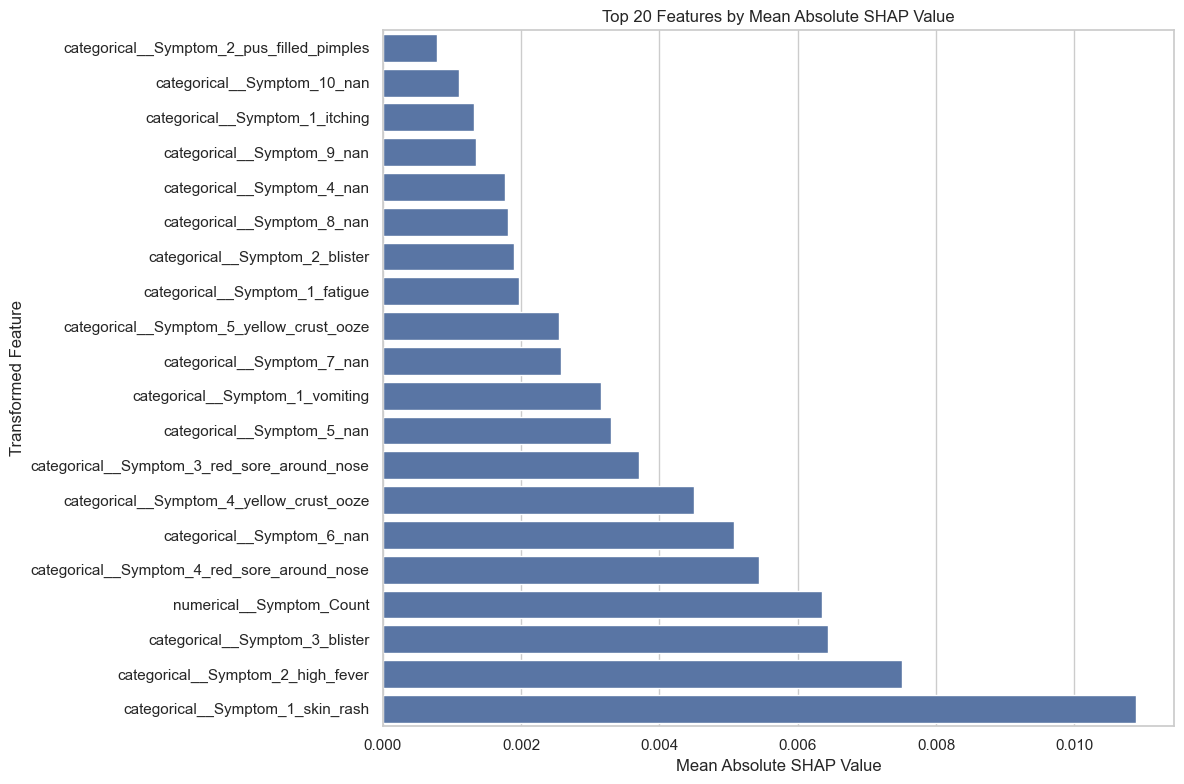

In [19]:

# Select top 20 features

top_features = (
    global_importance
    .head(20)
    .sort_values(
        by="Mean_Absolute_SHAP",
        ascending=True
    )
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_features,
    x="Mean_Absolute_SHAP",
    y="Feature"
)

plt.title(
    "Top 20 Features by Mean Absolute SHAP Value"
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Transformed Feature")

plt.tight_layout()
plt.show()


# 19. SHAP Summary Plot

The SHAP beeswarm plot displays the distribution of feature
contributions across the explanation samples.

The plot helps identify:

- Features with large contribution magnitudes
- The direction of feature contributions
- Variation in feature effects across observations

The interpretation is specific to the selected disease probability.

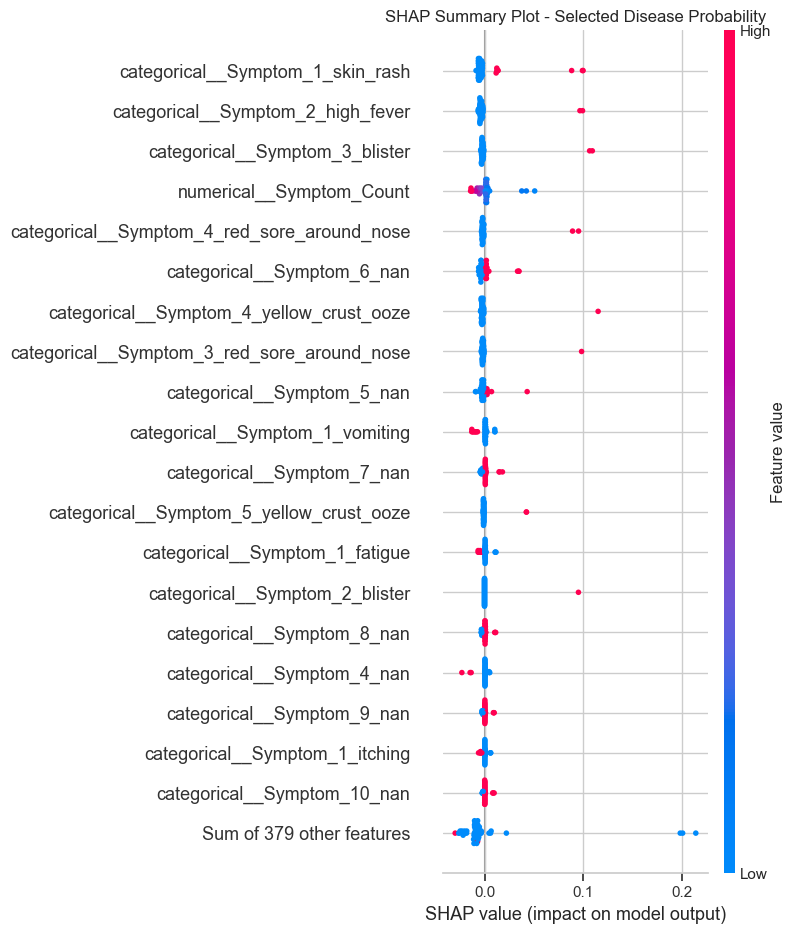

In [20]:

# SHAP beeswarm plot

plt.figure(figsize=(12, 8))

shap.plots.beeswarm(
    shap_values,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Summary Plot - Selected Disease Probability"
)

plt.tight_layout()
plt.show()


# 20. SHAP Bar Plot

The SHAP bar plot provides a global summary of feature importance
based on mean absolute SHAP values.

It provides a compact visualization for project documentation
and presentation.

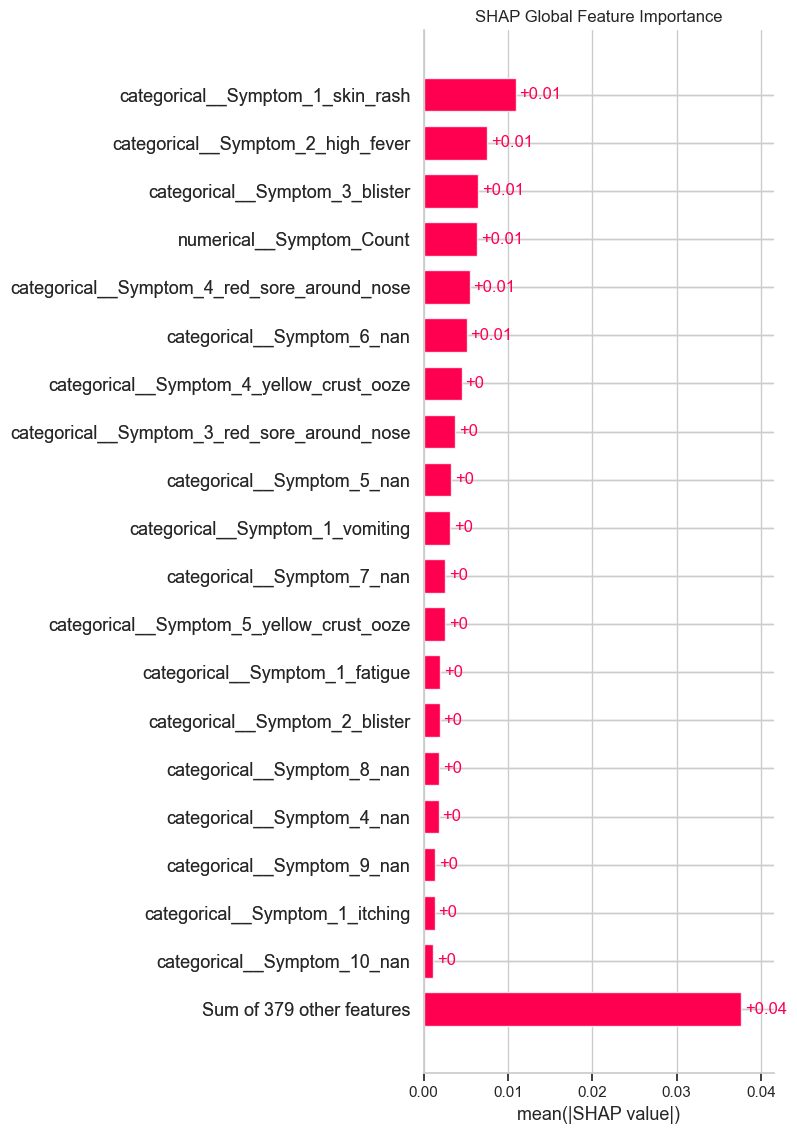

In [21]:

# SHAP global bar plot

plt.figure(figsize=(12, 8))

shap.plots.bar(
    shap_values,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Global Feature Importance"
)

plt.tight_layout()
plt.show()


# 21. Individual Prediction Explanation

Global importance shows the average behavior of the model across
multiple samples.

A local explanation examines one individual sample.

We will select one test observation and inspect the contribution
of transformed features to the selected disease probability.

The selected sample is an example of model interpretation and
should not be treated as a clinical explanation.

In [22]:

# Select the first explained observation

local_index = 0

local_sample = X_explain_dense[
    local_index:local_index + 1
]

local_shap_values = explainer(
    local_sample,
    max_evals="auto"
)

local_probability = (
    selected_class_probability(
        local_sample
    )[0]
)

print("Local explanation generated.")

print("Explained disease class:", selected_class_name)

print(
    "Selected class probability:",
    round(float(local_probability), 4)
)

Local explanation generated.
Explained disease class: Impetigo
Selected class probability: 0.0034



# 22. Local SHAP Waterfall Plot

The waterfall plot shows how feature contributions combine to move
the model output from the reference expectation toward the output
for one selected observation.

Positive contributions increase the explained output, while negative
contributions decrease it.

This is a model explanation for one selected disease probability.

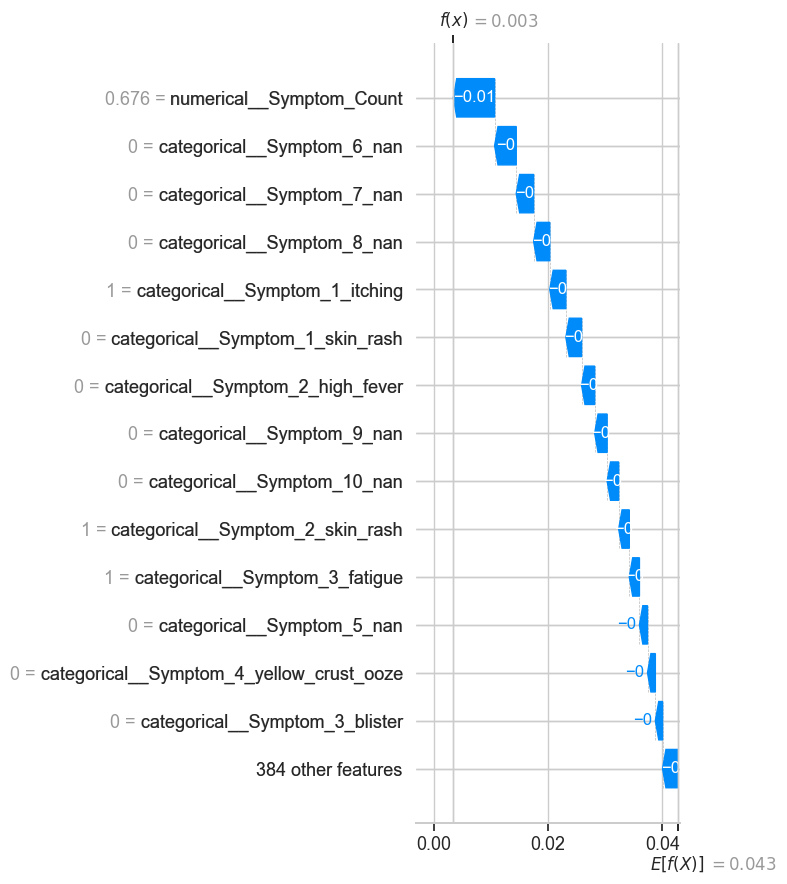

In [23]:

# Local waterfall plot

shap.plots.waterfall(
    local_shap_values[0],
    max_display=15,
    show=False
)

plt.tight_layout()
plt.show()


# 23. Inspect the Original Input Sample

The transformed feature representation contains encoded categorical
features.

To understand a local explanation, we also inspect the original
symptom values from the corresponding test observation.

This helps connect the model's transformed features to the original
dataset representation.

In [24]:

# Retrieve original sample

original_sample = X_test.iloc[
    explanation_indices[local_index]
]

print("Original input sample:")

display(
    original_sample.to_frame(
        name="Value"
    )
)

Original input sample:


,Value
Symptom_1,itching
Symptom_2,skin_rash
Symptom_3,fatigue
Symptom_4,lethargy
Symptom_5,high_fever
Symptom_6,headache
Symptom_7,loss_of_appetite
Symptom_8,mild_fever
Symptom_9,malaise
Symptom_10,red_spots_over_body



# 24. Compare Prediction with Actual Label

The original disease label is compared with the model's predicted
disease label.

This provides context for the local explanation.

The explanation itself describes the selected disease probability,
which may differ from the predicted class of the sample.

In [25]:

# Predict the original sample

original_sample_df = X_test.iloc[
    [explanation_indices[local_index]]
]

predicted_disease = (
    best_pipeline.predict(
        original_sample_df
    )[0]
)

actual_disease = (
    y_test.iloc[
        explanation_indices[local_index]
    ]
)

predicted_probabilities = (
    best_pipeline.predict_proba(
        original_sample_df
    )[0]
)

predicted_probability = (
    predicted_probabilities.max()
)

print("=" * 60)
print("LOCAL PREDICTION ANALYSIS")
print("=" * 60)

print("Actual Disease:", actual_disease)

print("Predicted Disease:", predicted_disease)

print(
    "Predicted Disease Probability:",
    round(float(predicted_probability), 4)
)

print(
    "Explained Disease Class:",
    selected_class_name
)

print(
    "Explained Class Probability:",
    round(float(local_probability), 4)
)

LOCAL PREDICTION ANALYSIS
Actual Disease: Chicken pox
Predicted Disease: Chicken pox
Predicted Disease Probability: 0.7823
Explained Disease Class: Impetigo
Explained Class Probability: 0.0034



# 25. Top Positive and Negative SHAP Contributions

The local SHAP values are used to identify transformed features
with the largest positive and negative contributions to the selected
disease probability.

These results can be used to support the model interpretation section
of the project report.

They should be described as predictive model contributions, not
medical causal effects.

In [26]:

# Create local contribution table

local_values = local_shap_values.values[0]

local_feature_values = local_sample[0]

local_importance = pd.DataFrame({
    "Feature": feature_names,
    "Feature_Value": local_feature_values,
    "SHAP_Value": local_values
})

# Sort by positive contributions
positive_contributions = (
    local_importance
    .sort_values(
        by="SHAP_Value",
        ascending=False
    )
    .head(10)
)

# Sort by negative contributions
negative_contributions = (
    local_importance
    .sort_values(
        by="SHAP_Value",
        ascending=True
    )
    .head(10)
)

print("Top positive contributions:")
display(positive_contributions)

print("\nTop negative contributions:")
display(negative_contributions)

Top positive contributions:


,Feature,Feature_Value,SHAP_Value
27,categorical__Symptom_1_vomiting,0.0,0.000570
11,categorical__Symptom_1_fatigue,0.0,0.000470
182,categorical__Symptom_4_nan,0.0,0.000338
103,categorical__Symptom_3_high_fever,0.0,0.000185
63,categorical__Symptom_2_pus_filled_pimples,0.0,0.000168
361,categorical__Symptom_11_nan,1.0,0.000167
62,categorical__Symptom_2_patches_in_throat,0.0,0.000166
17,categorical__Symptom_1_muscle_wasting,0.0,0.000157
112,categorical__Symptom_3_nausea,0.0,0.000148
168,categorical__Symptom_4_scurring,0.0,0.000144



Top negative contributions:


,Feature,Feature_Value,SHAP_Value
397,numerical__Symptom_Count,0.675727,-0.007220
252,categorical__Symptom_6_nan,0.000000,-0.003788
278,categorical__Symptom_7_nan,0.000000,-0.003040
299,categorical__Symptom_8_nan,0.000000,-0.002824
15,categorical__Symptom_1_itching,1.000000,-0.002814
23,categorical__Symptom_1_skin_rash,0.000000,-0.002751
50,categorical__Symptom_2_high_fever,0.000000,-0.002291
321,categorical__Symptom_9_nan,0.000000,-0.002181
342,categorical__Symptom_10_nan,0.000000,-0.002016
67,categorical__Symptom_2_skin_rash,1.000000,-0.001860



# 26. Save SHAP Analysis Results

The SHAP results are saved for:

- Project documentation
- Research paper preparation
- Presentation
- Future model analysis

The saved files include:

1. Global SHAP feature importance
2. Local SHAP feature contributions
3. Selected explanation metadata

In [27]:

# Save global importance

global_importance.to_csv(
    SHAP_OUTPUT_DIR / "global_shap_importance.csv",
    index=False
)

# Save local feature contributions

local_importance.to_csv(
    SHAP_OUTPUT_DIR / "local_shap_contributions.csv",
    index=False
)

# Save selected explanation metadata

explanation_metadata = pd.DataFrame({
    "Item": [
        "Explained Disease Class",
        "Selected Class Index",
        "Local Predicted Disease",
        "Local Actual Disease",
        "Local Predicted Probability",
        "Local Explained Class Probability"
    ],
    "Value": [
        selected_class_name,
        selected_class_index,
        predicted_disease,
        actual_disease,
        predicted_probability,
        local_probability
    ]
})

explanation_metadata.to_csv(
    SHAP_OUTPUT_DIR / "explanation_metadata.csv",
    index=False
)

print("SHAP results saved successfully.")

print(f"Output directory: {SHAP_OUTPUT_DIR}")

SHAP results saved successfully.
Output directory: ..\data\processed\shap_outputs



# 27. Save SHAP Visualization

The global feature importance visualization is saved as a PNG image.

This image can be used in the project report or presentation.

The visualization represents the selected disease probability.

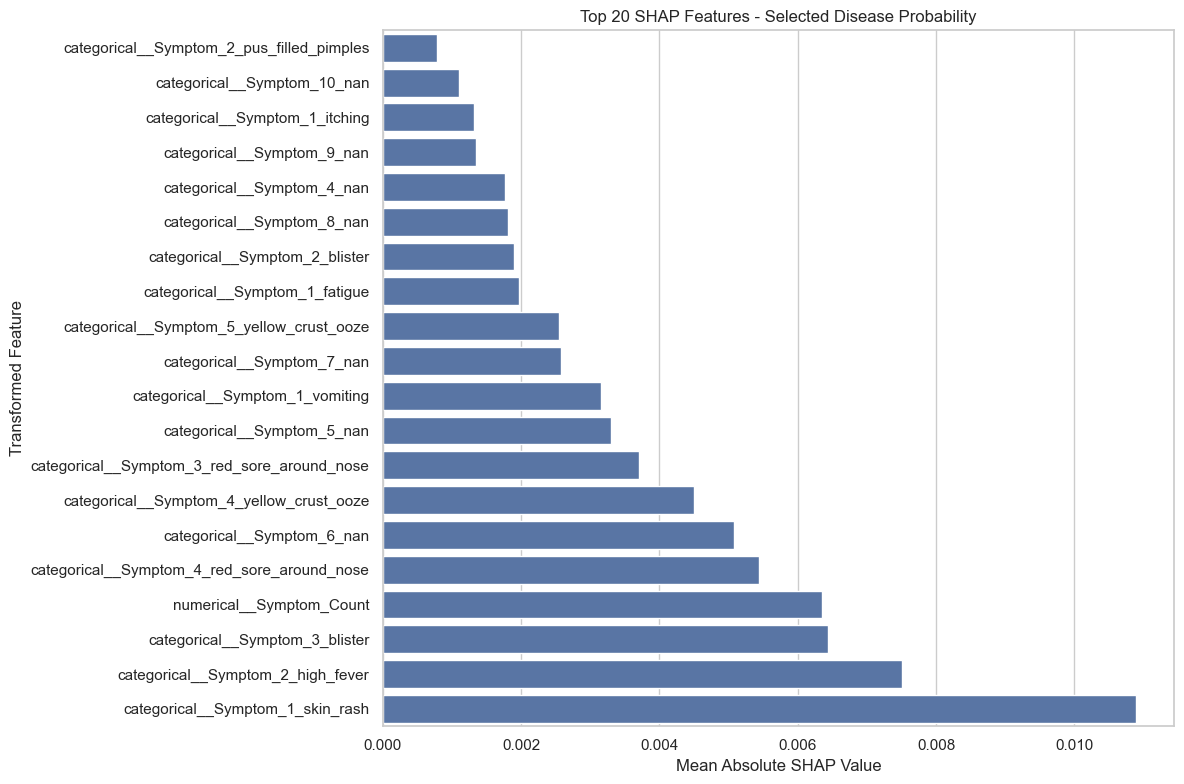

Global SHAP plot saved successfully.


In [28]:

# Save global feature importance plot

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_features,
    x="Mean_Absolute_SHAP",
    y="Feature"
)

plt.title(
    "Top 20 SHAP Features - Selected Disease Probability"
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Transformed Feature")

plt.tight_layout()

plt.savefig(
    SHAP_OUTPUT_DIR / "global_shap_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Global SHAP plot saved successfully.")


# 28. Final SHAP Analysis Validation

Before completing the notebook, we verify that:

- SHAP values were generated.
- Global importance results exist.
- Local contribution results exist.
- Output files were saved successfully.

These checks confirm that the explainability workflow completed
successfully.

In [29]:

# Final validation

assert len(global_importance) > 0, (
    "Global importance is empty."
)

assert len(local_importance) > 0, (
    "Local importance is empty."
)

assert shap_values.values.shape[1] == len(
    feature_names
), (
    "SHAP feature count does not match feature names."
)

print("=" * 60)
print("FINAL SHAP VALIDATION")
print("=" * 60)

print("✓ SHAP values generated")
print("✓ Global importance generated")
print("✓ Local contributions generated")
print("✓ Feature name validation passed")

print("\nSaved files:")

for file in sorted(
    SHAP_OUTPUT_DIR.iterdir()
):
    print("✓", file.name)

FINAL SHAP VALIDATION
✓ SHAP values generated
✓ Global importance generated
✓ Local contributions generated
✓ Feature name validation passed

Saved files:
✓ explanation_metadata.csv
✓ global_shap_importance.csv
✓ global_shap_importance.png
✓ local_shap_contributions.csv



# 29. Final Conclusion

## Model Explainability Completed

This notebook performed SHAP-based model interpretation for the
AI Disease Prediction System.

### Completed Tasks

- Loaded the processed dataset
- Loaded the trained machine learning pipeline
- Recreated the train-test split
- Extracted the fitted preprocessor
- Transformed the test data
- Extracted transformed feature names
- Prepared SHAP background and explanation samples
- Created a permutation-based SHAP explainer
- Calculated SHAP values for a selected disease probability
- Generated global feature importance analysis
- Generated SHAP summary visualizations
- Generated local prediction explanations
- Analyzed positive and negative feature contributions
- Saved SHAP analysis results and visualizations

### Important Interpretation

SHAP values describe the contribution of model features to a
prediction. They do not establish medical causality or guarantee
that the model's output is medically correct.

The analysis is based on the current dataset, preprocessing pipeline,
and trained model.

### Output

The SHAP analysis results have been saved to:

`data/processed/shap_outputs/`

The project can now proceed toward:

**API Development → Application Integration → Deployment**